#  Практическое занятие: Git · Python · SQL
## База данных (музыкальный магазин)

---
###  Содержание
| # | Раздел |
|---|--------|
| **ЗАНЯТИЕ 1** | |
| 1 | [ Подготовка среды](#setup) |
| 2 | [ Git и GitHub — основы](#git) |
| 3 | [ Подключение к БД и знакомство с данными](#connect) |
| 4 | [SQL: SELECT, WHERE, ORDER BY](#sql-basic) |
| 5 | [SQL: JOIN и GROUP BY](#sql-join) |
| 6 | [ Самостоятельные задания — Занятие 1](#tasks1) |
| 7 | [ Домашнее задание — после Занятия 1](#hw1) |
| **ЗАНЯТИЕ 2** | |
| 8 | [ Продвинутый SQL: подзапросы и HAVING](#subqueries) |
| 9 | [CTE — Common Table Expressions](#cte) |
| 10 | [Оконные функции](#window) |
| 11 | [ Git: ветки и слияния](#branches) |
| 12 | [ Комплексный анализ данных](#analysis) |
| 13 | [ Самостоятельные задания — Занятие 2](#tasks2) |
| 14 | [ Итоговое домашнее задание](#hw-final) |

---
>  **Как работать с ноутбуком:** запускайте ячейки по порядку (Shift+Enter).
> Ячейки с `# DEMO` — **примеры для изучения**.
> Ячейки с `#  ЗАДАНИЕ` — **ваш код** (замените `# TODO`).


---
<a id="setup"></a>
## Часть 0. Подготовка среды
Выполните ячейки этого раздела **один раз** перед началом занятия.


In [2]:
# Установка библиотек (раскомментируйте если нужно)
!pip install -q pandas matplotlib seaborn

import os

DB_FILE = "tgu_practice_db.db"

if os.path.exists(DB_FILE):
    print(f"База данных найдена: {DB_FILE}  ({os.path.getsize(DB_FILE)//1024} KB)")
else:
    print(f"БД не найдена: {DB_FILE}")


База данных найдена: tgu_practice_db.db  (984 KB)


In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["figure.dpi"]  = 110
warnings.filterwarnings("ignore")

conn = sqlite3.connect(DB_FILE)

def sql(query):
    """Выполняет SQL-запрос → возвращает pandas DataFrame."""
    return pd.read_sql_query(query, conn)

print("Подключение к базе данных установлено")
print(f"   SQLite : {sqlite3.sqlite_version}")
print(f"   pandas : {pd.__version__}")


Подключение к базе данных установлено
   SQLite : 3.51.2
   pandas : 3.0.2


### Схема базы данных

Учебная БД музыкального магазина (аналог iTunes).

```
Artist ──< Album ──< Track >──< InvoiceLine >──< Invoice >──< Customer
                       │
                    Genre · MediaType · PlaylistTrack
```

| Таблица | Строк | Описание |
|---------|------:|---------|
| `Artist` | 275 | Исполнители |
| `Album` | 347 | Альбомы |
| `Track` | 3 503 | Треки (название, жанр, длина, цена) |
| `Genre` | 25 | Жанры музыки |
| `MediaType` | 5 | Форматы файлов |
| `Customer` | 59 | Покупатели (имя, страна, агент) |
| `Invoice` | 412 | Заказы (дата, сумма) |
| `InvoiceLine` | 2 240 | Строки заказов |
| `Employee` | 8 | Сотрудники (иерархия) |
| `Playlist` | 18 | Плейлисты |
| `PlaylistTrack` | 8 715 | Связь плейлист ↔ трек |


In [4]:
# DEMO ── Список таблиц ──────────────────────────────────────────────────────
sql("SELECT name, type FROM sqlite_master WHERE type='table' ORDER BY name")


,name,type
0,Album,table
1,Artist,table
2,Customer,table
3,Employee,table
4,Genre,table
5,Invoice,table
6,InvoiceLine,table
7,MediaType,table
8,Playlist,table
9,PlaylistTrack,table


In [ ]:
# DEMO ── Структура таблицы Track ─────────────────────────────────────────────
print("Структура таблицы Track:")
display(sql("PRAGMA table_info(Track)"))


Структура таблицы Track:


,cid,name,type,notnull,dflt_value,pk
0,0,TrackId,INTEGER,1,None,1
1,1,Name,NVARCHAR(200),1,None,0
2,2,AlbumId,INTEGER,0,None,0
3,3,MediaTypeId,INTEGER,1,None,0
4,4,GenreId,INTEGER,0,None,0
5,5,Composer,NVARCHAR(220),0,None,0
6,6,Milliseconds,INTEGER,1,None,0
7,7,Bytes,INTEGER,0,None,0
8,8,UnitPrice,"NUMERIC(10,2)",1,None,0


In [ ]:
# DEMO ── Первые строки ключевых таблиц ────────────────────────────────────────
for table in ["Artist", "Album", "Track", "Customer", "Invoice"]:
    print(f"\n── {table} (первые 3 строки) ─")
    display(sql(f"SELECT * FROM {table} LIMIT 3"))



── Artist (первые 3 строки) ─


,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith



── Album (первые 3 строки) ─


,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2



── Track (первые 3 строки) ─


,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99



── Customer (первые 3 строки) ─


,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,None,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,+49 0711 2842222,None,leonekohler@surfeu.de,5
2,3,François,Tremblay,None,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,None,ftremblay@gmail.com,3



── Invoice (первые 3 строки) ─


,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2021-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2021-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,3,8,2021-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94


---
<a id="git"></a>
## Часть 1. Git и GitHub — основы

### Что такое Git?
Git — **система контроля версий**: сохраняет историю всех изменений файлов.
GitHub — облачное хранилище репозиториев.

### Три зоны Git
```
Рабочая папка  →  git add  →  Staging Area  →  git commit  →  Local Repo  →  git push  →  GitHub
```

### Шпаргалка по командам

| Команда | Описание |
|---------|----------|
| `git init` | Создать репозиторий |
| `git clone <url>` | Скопировать с GitHub |
| `git status` | Состояние файлов |
| `git add <файл>` | Добавить в staging |
| `git add .` | Добавить всё |
| `git commit -m "msg"` | Зафиксировать коммит |
| `git push` | Отправить на GitHub |
| `git pull` | Получить с GitHub |
| `git log --oneline` | История коммитов |
| `git checkout -b name` | Создать и переключиться на ветку |
| `git merge name` | Слить ветку |

> **Push из Google Colab требует Personal Access Token (PAT):**
> GitHub → Settings → Developer Settings → Personal Access Tokens → Generate new token → права `repo`
> Используйте: `git push https://TOKEN@github.com/USER/REPO.git main`


---
<a id="connect"></a>
<a id="sql-basic"></a>
## Часть 2. Python + SQL: первые запросы

### SELECT — выборка данных

```sql
SELECT колонка1, колонка2, выражение AS псевдоним
FROM таблица
WHERE условие
ORDER BY колонка DESC
LIMIT количество;
```


In [37]:
# DEMO ── SELECT: все исполнители (первые 10) ─────────────────────────────────
sql("SELECT * FROM Artist LIMIT 10")


,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains
5,6,Antônio Carlos Jobim
6,7,Apocalyptica
7,8,Audioslave
8,9,BackBeat
9,10,Billy Cobham


In [38]:
# DEMO ── SELECT с вычисляемым полем: длина треков в минутах ─────────────────
sql("""
SELECT
    Name                               AS Название,
    Composer                           AS Автор,
    ROUND(Milliseconds / 60000.0, 2)   AS Минуты,
    UnitPrice                          AS Цена_USD
FROM Track
ORDER BY Milliseconds DESC
LIMIT 10
""")


,Название,Автор,Минуты,Цена_USD
0,Occupation / Precipice,None,88.12,1.99
1,Through a Looking Glass,None,84.81,1.99
2,"Greetings from Earth, Pt. 1",None,49.34,1.99
3,The Man With Nine Lives,None,49.28,1.99
4,"Battlestar Galactica, Pt. 2",None,49.27,1.99
5,"Battlestar Galactica, Pt. 1",None,49.21,1.99
6,Murder On the Rising Star,None,48.93,1.99
7,"Battlestar Galactica, Pt. 3",None,48.80,1.99
8,Take the Celestra,None,48.79,1.99
9,Fire In Space,None,48.78,1.99


### WHERE — фильтрация строк

| Оператор | Пример | Смысл |
|----------|--------|-------|
| `=` | `Country = 'USA'` | точное совпадение |
| `<>` | `UnitPrice <> 0.99` | не равно |
| `LIKE 'A%'` | `Name LIKE 'A%'` | начинается на A |
| `IN (...)` | `Country IN ('USA','Canada')` | из списка |
| `BETWEEN a AND b` | `Milliseconds BETWEEN 300000 AND 600000` | диапазон |
| `IS NULL` | `SupportRepId IS NULL` | пустое значение |


In [39]:
# DEMO ── WHERE: исполнители, чьё имя начинается на «A» ─────────────────────
sql("SELECT ArtistId, Name FROM Artist WHERE Name LIKE 'A%' ORDER BY Name")


,ArtistId,Name
0,43,A Cor Do Som
1,1,AC/DC
2,230,Aaron Copland & London Symphony Orchestra
3,202,Aaron Goldberg
4,214,Academy of St. Martin in the Fields & Sir Nevi...
5,215,Academy of St. Martin in the Fields Chamber En...
6,222,"Academy of St. Martin in the Fields, John Birc..."
7,257,"Academy of St. Martin in the Fields, Sir Nevil..."
8,239,"Academy of St. Martin in the Fields, Sir Nevil..."
9,2,Accept


In [40]:
# DEMO ── WHERE: покупатели из USA и Canada ──────────────────────────────────
sql("""
SELECT FirstName, LastName, Country, Email
FROM Customer
WHERE Country IN ('USA', 'Canada')
ORDER BY Country, LastName
""")


,FirstName,LastName,Country,Email
0,Robert,Brown,Canada,robbrown@shaw.ca
1,Edward,Francis,Canada,edfrancis@yachoo.ca
2,Aaron,Mitchell,Canada,aaronmitchell@yahoo.ca
3,Jennifer,Peterson,Canada,jenniferp@rogers.ca
4,Mark,Philips,Canada,mphilips12@shaw.ca
5,Martha,Silk,Canada,marthasilk@gmail.com
6,Ellie,Sullivan,Canada,ellie.sullivan@shaw.ca
7,François,Tremblay,Canada,ftremblay@gmail.com
8,Julia,Barnett,USA,jubarnett@gmail.com
9,Michelle,Brooks,USA,michelleb@aol.com


In [41]:
# DEMO ── ORDER BY: топ-10 самых дорогих треков ───────────────────────────────
sql("""
SELECT Name, UnitPrice
FROM Track
ORDER BY UnitPrice DESC
LIMIT 10
""")


,Name,UnitPrice
0,Battlestar Galactica: The Story So Far,1.99
1,Occupation / Precipice,1.99
2,"Exodus, Pt. 1",1.99
3,"Exodus, Pt. 2",1.99
4,Collaborators,1.99
5,Torn,1.99
6,A Measure of Salvation,1.99
7,Hero,1.99
8,Unfinished Business,1.99
9,The Passage,1.99


---
<a id="sql-join"></a>
### JOIN — объединение таблиц

```sql
SELECT *
FROM ТаблицаА a
JOIN ТаблицаБ b ON a.ключ = b.ключ   -- INNER JOIN: только совпадения
LEFT JOIN ТаблицаВ c ON ...           -- LEFT JOIN: все из левой
```


In [42]:
# DEMO ── JOIN: исполнитель + альбом ──────────────────────────────────────────
sql("""
SELECT ar.Name  AS Исполнитель,
       al.Title AS Альбом
FROM Artist ar
JOIN Album  al ON ar.ArtistId = al.ArtistId
ORDER BY ar.Name
LIMIT 15
""")


,Исполнитель,Альбом
0,AC/DC,For Those About To Rock We Salute You
1,AC/DC,Let There Be Rock
2,Aaron Copland & London Symphony Orchestra,"A Copland Celebration, Vol. I"
3,Aaron Goldberg,Worlds
4,Academy of St. Martin in the Fields & Sir Nevi...,The World of Classical Favourites
5,Academy of St. Martin in the Fields Chamber En...,Sir Neville Marriner: A Celebration
6,"Academy of St. Martin in the Fields, John Birc...","Fauré: Requiem, Ravel: Pavane & Others"
7,"Academy of St. Martin in the Fields, Sir Nevil...",Bach: Orchestral Suites Nos. 1 - 4
8,Accept,Balls to the Wall
9,Accept,Restless and Wild


In [43]:
# DEMO ── JOIN цепочка: Artist → Album → Track → Genre ────────────────────────
sql("""
SELECT ar.Name   AS Исполнитель,
       al.Title  AS Альбом,
       t.Name    AS Трек,
       g.Name    AS Жанр,
       ROUND(t.Milliseconds / 60000.0, 1) AS Минуты
FROM Track  t
JOIN Album  al ON t.AlbumId  = al.AlbumId
JOIN Artist ar ON al.ArtistId = ar.ArtistId
JOIN Genre  g  ON t.GenreId   = g.GenreId
WHERE ar.Name = 'AC/DC'
ORDER BY al.Title, t.Name
""")


,Исполнитель,Альбом,Трек,Жанр,Минуты
0,AC/DC,For Those About To Rock We Salute You,Breaking The Rules,Rock,4.4
1,AC/DC,For Those About To Rock We Salute You,C.O.D.,Rock,3.3
2,AC/DC,For Those About To Rock We Salute You,Evil Walks,Rock,4.4
3,AC/DC,For Those About To Rock We Salute You,For Those About To Rock (We Salute You),Rock,5.7
4,AC/DC,For Those About To Rock We Salute You,Inject The Venom,Rock,3.5
5,AC/DC,For Those About To Rock We Salute You,Let's Get It Up,Rock,3.9
6,AC/DC,For Those About To Rock We Salute You,Night Of The Long Knives,Rock,3.4
7,AC/DC,For Those About To Rock We Salute You,Put The Finger On You,Rock,3.4
8,AC/DC,For Those About To Rock We Salute You,Snowballed,Rock,3.4
9,AC/DC,For Those About To Rock We Salute You,Spellbound,Rock,4.5


### GROUP BY + агрегатные функции

| Функция | Смысл |
|---------|-------|
| `COUNT(*)` | количество строк |
| `SUM(col)` | сумма |
| `AVG(col)` | среднее |
| `MIN(col)` / `MAX(col)` | минимум / максимум |
| `ROUND(x, n)` | округление до n знаков |

> В `SELECT` при `GROUP BY` можно использовать **только** группирующие поля и агрегаты!


In [44]:
# DEMO ── GROUP BY: треков по жанру ──────────────────────────────────────────
df_genres = sql("""
SELECT g.Name         AS Жанр,
       COUNT(t.TrackId)  AS Треков,
       ROUND(AVG(t.Milliseconds)/60000.0, 1) AS Ср_длина_мин
FROM Genre g
JOIN Track t ON g.GenreId = t.GenreId
GROUP BY g.GenreId
ORDER BY Треков DESC
""")
display(df_genres.head(12))


,Жанр,Треков,Ср_длина_мин
0,Rock,1297,4.7
1,Latin,579,3.9
2,Metal,374,5.2
3,Alternative & Punk,332,3.9
4,Jazz,130,4.9
5,TV Shows,93,35.8
6,Blues,81,4.5
7,Classical,74,4.9
8,Drama,64,42.9
9,R&B/Soul,61,3.7


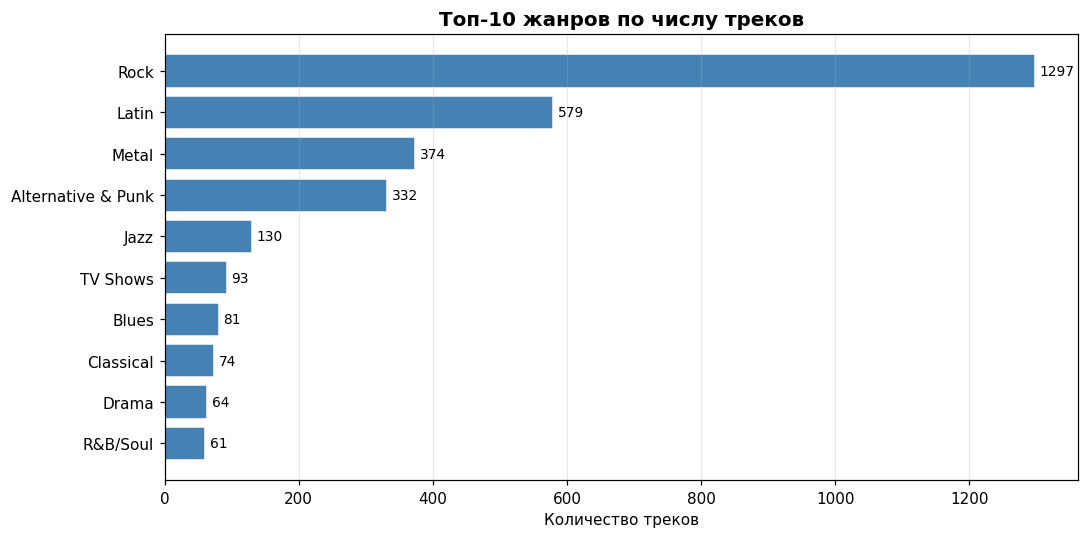

In [45]:
# DEMO ── Визуализация: топ-10 жанров по числу треков ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
df_top = df_genres.head(10)
bars = ax.barh(df_top["Жанр"][::-1], df_top["Треков"][::-1],
               color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Количество треков")
ax.set_title("Топ-10 жанров по числу треков", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("genres_bar.png", dpi=120, bbox_inches="tight")
plt.show()


In [46]:
# DEMO ── GROUP BY: исполнители с наибольшим числом альбомов ─────────────────
sql("""
SELECT ar.Name            AS Исполнитель,
       COUNT(al.AlbumId)  AS Альбомов,
       COUNT(t.TrackId)   AS Треков
FROM Artist ar
JOIN Album  al ON ar.ArtistId = al.ArtistId
JOIN Track  t  ON al.AlbumId  = t.AlbumId
GROUP BY ar.ArtistId
ORDER BY Альбомов DESC, Треков DESC
LIMIT 10
""")


,Исполнитель,Альбомов,Треков
0,Iron Maiden,213,213
1,U2,135,135
2,Led Zeppelin,114,114
3,Metallica,112,112
4,Deep Purple,92,92
5,Lost,92,92
6,Pearl Jam,67,67
7,Lenny Kravitz,57,57
8,Various Artists,56,56
9,The Office,53,53


---
<a id="tasks1"></a>
## Самостоятельные задания — Занятие 1
> Выполните все задания в этом ноутбуке.
> После выполнения сохраните файл и загрузите на GitHub.

---
### Задание 1.1 — Git
1. Создайте файл `README.md` с описанием проекта (2–3 предложения).
2. Сделайте коммит с осмысленным сообщением и запушьте на GitHub.

```bash
# %%bash
# echo "# Mini Analysis" > README.md
# git add README.md
# git commit -m "Add project README with description"
# git push ...
```


### Задание 1.2 — SQL

Ответьте на каждый вопрос в отдельной ячейке кода.


In [22]:
# ЗАДАНИЕ 1.2.1
# Сколько треков есть в каждом жанре?
# Выведите: жанр и количество треков, отсортируйте по убыванию.
# Таблицы: Track, Genre  |  Ключ: Track.GenreId = Genre.GenreId
# Ожидаемый результат: 25 строк, первый жанр — Rock (~1297 треков)

# TODO: ваш код здесь
sql("""
    SELECT g.Name, COUNT(t.TrackId) as count
    FROM Genre g
    JOIN Track t on t.GenreId = g.GenreId
    GROUP BY g.Name
    ORDER BY count DESC
    LIMIT 25
    """)


,Name,count
0,Rock,1297
1,Latin,579
2,Metal,374
3,Alternative & Punk,332
4,Jazz,130
5,TV Shows,93
6,Blues,81
7,Classical,74
8,Drama,64
9,R&B/Soul,61


In [24]:
# ЗАДАНИЕ 1.2.2
# Какие 5 треков самые длинные по времени?
# Выведите: название и длину в минутах (округлить до 1 знака).
# Таблица: Track, поле Milliseconds
# Подсказка: длина в минутах = Milliseconds / 60000.0

# TODO: ваш код здесь

sql("""
    SELECT Name, ROUND(Milliseconds/60000.0,1) as time
    FROM Track
    ORDER BY time DESC
    LIMIT 5
    """)

,Name,time
0,Occupation / Precipice,88.1
1,Through a Looking Glass,84.8
2,"Battlestar Galactica, Pt. 2",49.3
3,The Man With Nine Lives,49.3
4,"Greetings from Earth, Pt. 1",49.3


In [29]:
# ЗАДАНИЕ 1.2.3
# Сколько альбомов у группы «Iron Maiden»?
# Таблицы: Artist, Album
# Подсказка: WHERE ar.Name = 'Iron Maiden'

# TODO: ваш код здесь

sql("""
    SELECT COUNT(al.Title)
    FROM Album al
    JOIN Artist a on al.ArtistId = a.ArtistId
    WHERE a.Name = 'Iron Maiden'
    """)

,COUNT(al.Title)
0,21


In [30]:
# ЗАДАНИЕ 1.2.4
# Выведите имена и фамилии всех покупателей из Бразилии.
# Таблица: Customer, поля FirstName, LastName, Country
# Ожидаемый результат: 5 покупателей

# TODO: ваш код здесь
sql("""
    SELECT FirstName, LastName
    FROM Customer c
    WHERE Country = "Brazil"
    """)


,FirstName,LastName
0,Luís,Gonçalves
1,Eduardo,Martins
2,Alexandre,Rocha
3,Roberto,Almeida
4,Fernanda,Ramos


### Задание 1.3 — Python + pandas


In [51]:
# ЗАДАНИЕ 1.3
# 1. Выполните SQL-запрос и сохраните результат в переменную df
# 2. Выведите df.shape, df.dtypes, df.describe()
# 3. Постройте столбчатую диаграмму для топ-10 жанров по числу треков

# Шаг 1: SQL → df
df = sql("""
SELECT g.Name AS Жанр, COUNT(t.TrackId) AS Треков
FROM Genre g
JOIN Track t ON g.GenreId = t.GenreId
GROUP BY g.GenreId
ORDER BY Треков DESC
LIMIT 10
""")

# TODO: шаг 2 — изучение данных
# print("Размер:", df.shape)
# print(df.dtypes)
# display(df.describe())

print(df.shape())
print(df.dtypes)
display(df.describe())

# TODO: шаг 3 — столбчатая диаграмма
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.bar(df["Жанр"], df["Треков"])
# ax.set_title("Топ-10 жанров")
# ax.set_xlabel("Жанр")
# ax.set_ylabel("Треков")
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.show()




---
<a id="hw1"></a>
## Домашнее задание — после Занятия 1
> **Срок:** до начала Занятия 2.
> Оформите решения ниже (или создайте `homework1.ipynb`).
> Загрузите файл на GitHub в ветку `feature/analysis`.

---
### ДЗ-1: Исследование базы данных (обязательно)


In [40]:
sql("SELECT * FROM Invoice")

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2021-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,NaN,Germany,70174,1.98
1,2,4,2021-01-02 00:00:00,Ullevålsveien 14,Oslo,NaN,Norway,0171,3.96
2,3,8,2021-01-03 00:00:00,Grétrystraat 63,Brussels,NaN,Belgium,1000,5.94
3,4,14,2021-01-06 00:00:00,8210 111 ST NW,Edmonton,AB,Canada,T6G 2C7,8.91
4,5,23,2021-01-11 00:00:00,69 Salem Street,Boston,MA,USA,2113,13.86
...,...,...,...,...,...,...,...,...,...
407,408,25,2025-12-05 00:00:00,319 N. Frances Street,Madison,WI,USA,53703,3.96
408,409,29,2025-12-06 00:00:00,796 Dundas Street West,Toronto,ON,Canada,M6J 1V1,5.94
409,410,35,2025-12-09 00:00:00,"Rua dos Campeões Europeus de Viena, 4350",Porto,NaN,Portugal,NaN,8.91
410,411,44,2025-12-14 00:00:00,Porthaninkatu 9,Helsinki,NaN,Finland,00530,13.86


In [38]:
# ДЗ-1.1: Топ-10 исполнителей по суммарной выручке
# Таблицы: Artist → Album → Track → InvoiceLine
# Выручка = SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity)
# Ожидаемый результат: 10 строк, лидер — Iron Maiden (~138 $)

# TODO: ваш код
sql("""
    SELECT SUM(il.UnitPrice * il.Quantity) as total, ar.Name as name
    FROM Artist ar
    JOIN Album al ON al.ArtistId = ar.ArtistId
    JOIN Track tr ON tr.AlbumId = al.AlbumId
    JOIN InvoiceLine il ON il.TrackId = tr.TrackId
    GROUP BY ar.Name
    ORDER BY total DESC
    LIMIT 10
    """)


,total,name
0,138.60,Iron Maiden
1,105.93,U2
2,90.09,Metallica
3,86.13,Led Zeppelin
4,81.59,Lost
5,49.75,The Office
6,44.55,Os Paralamas Do Sucesso
7,43.56,Deep Purple
8,41.58,Faith No More
9,39.60,Eric Clapton


In [39]:
# ДЗ-1.2: Страна с наибольшим количеством покупателей
# Таблица: Customer, поле Country
# Подсказка: GROUP BY Country  ORDER BY COUNT(*) DESC  LIMIT 5

# TODO: ваш код

sql("""
    SELECT Country, COUNT(*) as count
    FROM Customer
    GROUP BY Country
    ORDER BY count DESC
    LIMIT 5
    """)

,Country,count
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4


In [43]:
# ДЗ-1.3: В каком году было больше всего заказов?
# Таблица: Invoice, поле InvoiceDate
# Подсказка: strftime('%Y', InvoiceDate) → год в виде строки

# TODO: ваш код
sql("""
    SELECT strftime('%Y', InvoiceDate) as date, COUNT(*) as count
    FROM Invoice
    GROUP BY date
    ORDER BY date DESC
    LIMIT 1
    """)


,date,count
0,2025,80


### ДЗ-2: Git workflow (обязательно)


In [ ]:
# ДЗ-2: Создайте ветку и загрузите ноутбук
# Раскомментируйте и выполните:

# !git checkout -b feature/analysis
# !git add practice_git_python_sql.ipynb
# !git commit -m "Add homework 1: SQL analysis"
# !git push https://YOUR_TOKEN@github.com/YOUR_USERNAME/mini-analysis.git feature/analysis
# Затем на GitHub создайте Pull Request: feature/analysis → main

print("Раскомментируйте и выполните команды выше")


Раскомментируйте и выполните команды выше


### ДЗ-3: Визуализация


In [54]:
# ДЗ-3: Постройте 2 информативных графика
# Требования: заголовок на русском, подписи осей, аккуратный вид.
#
# Идеи:
#   - Круговая диаграмма: доля каждой страны в выручке
#   - Линейный: выручка по месяцам
#   - Bar chart: топ-10 исполнителей по числу треков

# TODO: График 1



# TODO: График 2




---
---
#  ЗАНЯТИЕ 2
## Продвинутый SQL · Git-ветки · Анализ данных на Python


---
<a id="subqueries"></a>
## Часть 1. Продвинутый SQL

### Подзапросы (Subqueries)
Подзапрос — SELECT внутри другого SELECT.

```sql
SELECT * FROM Track
WHERE UnitPrice > (SELECT AVG(UnitPrice) FROM Track)
```


In [55]:
# DEMO ── Подзапрос: треки дороже средней цены ────────────────────────────────
avg_df = sql("SELECT ROUND(AVG(UnitPrice), 2) AS avg FROM Track")
print("Средняя цена трека:", avg_df["avg"][0], "$")

sql("""
SELECT Name, UnitPrice
FROM Track
WHERE UnitPrice > (SELECT AVG(UnitPrice) FROM Track)
ORDER BY UnitPrice DESC
LIMIT 10
""")


Средняя цена трека: 1.05 $


,Name,UnitPrice
0,Battlestar Galactica: The Story So Far,1.99
1,Occupation / Precipice,1.99
2,"Exodus, Pt. 1",1.99
3,"Exodus, Pt. 2",1.99
4,Collaborators,1.99
5,Torn,1.99
6,A Measure of Salvation,1.99
7,Hero,1.99
8,Unfinished Business,1.99
9,The Passage,1.99


### HAVING — фильтрация групп

| | `WHERE` | `HAVING` |
|--|---------|---------|
| Когда | до GROUP BY | после GROUP BY |
| Фильтрует | строки | группы |
| Может использовать агрегаты? | нет | да |


In [56]:
# DEMO ── HAVING: покупатели с более чем 7 заказами ──────────────────────────
sql("""
SELECT c.FirstName || ' ' || c.LastName AS Покупатель,
       c.Country,
       COUNT(i.InvoiceId)          AS Заказов,
       ROUND(SUM(i.Total), 2)      AS Сумма_USD
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId
HAVING COUNT(i.InvoiceId) > 7
ORDER BY Заказов DESC
""")


,Покупатель,Country,Заказов,Сумма_USD


---
<a id="cte"></a>
### CTE — Common Table Expressions

CTE делают сложные запросы **читаемыми**. Объявляем временную таблицу → используем.

```sql
WITH ИмяCTE AS (
    SELECT ...
),
ВторойCTE AS (
    SELECT ... FROM ИмяCTE ...
)
SELECT * FROM ВторойCTE;
```


In [57]:
# DEMO ── CTE: топ-5 исполнителей по суммарной выручке ───────────────────────
sql("""
WITH TrackRevenue AS (
    -- Шаг 1: выручка по треку
    SELECT t.TrackId,
           t.AlbumId,
           SUM(il.UnitPrice * il.Quantity) AS Revenue
    FROM Track t
    JOIN InvoiceLine il ON t.TrackId = il.TrackId
    GROUP BY t.TrackId
),
ArtistRevenue AS (
    -- Шаг 2: агрегируем по исполнителю
    SELECT ar.Name            AS Исполнитель,
           SUM(tr.Revenue)    AS Выручка
    FROM TrackRevenue tr
    JOIN Album  al ON tr.AlbumId  = al.AlbumId
    JOIN Artist ar ON al.ArtistId = ar.ArtistId
    GROUP BY ar.ArtistId
)
SELECT Исполнитель, ROUND(Выручка, 2) AS Выручка_USD
FROM ArtistRevenue
ORDER BY Выручка DESC
LIMIT 10
""")


,Исполнитель,Выручка_USD
0,Iron Maiden,138.60
1,U2,105.93
2,Metallica,90.09
3,Led Zeppelin,86.13
4,Lost,81.59
5,The Office,49.75
6,Os Paralamas Do Sucesso,44.55
7,Deep Purple,43.56
8,Faith No More,41.58
9,Eric Clapton,39.60


---
<a id="window"></a>
### Оконные функции (Window Functions)

Считают агрегаты **без GROUP BY** — строки сохраняются!

```sql
функция() OVER (
    PARTITION BY поле   -- группа
    ORDER BY поле       -- порядок внутри группы
)
```

| Функция | Описание |
|---------|----------|
| `ROW_NUMBER()` | Номер строки |
| `RANK()` | Ранг (с пропусками при ничьей) |
| `DENSE_RANK()` | Ранг без пропусков |
| `LAG(col, n)` | Значение n строк **назад** |
| `LEAD(col, n)` | Значение n строк **вперёд** |
| `SUM/AVG OVER(...)` | Нарастающий итог / скользящее среднее |


In [58]:
# DEMO ── RANK: рейтинг альбомов каждого исполнителя ─────────────────────────
sql("""
SELECT ar.Name   AS Исполнитель,
       al.Title  AS Альбом,
       COUNT(t.TrackId) AS Треков,
       SUM(COUNT(t.TrackId)) OVER (PARTITION BY ar.ArtistId) AS Всего_у_артиста,
       RANK() OVER (PARTITION BY ar.ArtistId
                   ORDER BY COUNT(t.TrackId) DESC)            AS Место
FROM Artist ar
JOIN Album  al ON ar.ArtistId = al.ArtistId
JOIN Track  t  ON al.AlbumId  = t.AlbumId
GROUP BY ar.ArtistId, al.AlbumId
ORDER BY ar.Name, Место
LIMIT 20
""")


,Исполнитель,Альбом,Треков,Всего_у_артиста,Место
0,AC/DC,For Those About To Rock We Salute You,10,18,1
1,AC/DC,Let There Be Rock,8,18,2
2,Aaron Copland & London Symphony Orchestra,"A Copland Celebration, Vol. I",1,1,1
3,Aaron Goldberg,Worlds,1,1,1
4,Academy of St. Martin in the Fields & Sir Nevi...,The World of Classical Favourites,2,2,1
5,Academy of St. Martin in the Fields Chamber En...,Sir Neville Marriner: A Celebration,1,1,1
6,"Academy of St. Martin in the Fields, John Birc...","Fauré: Requiem, Ravel: Pavane & Others",1,1,1
7,"Academy of St. Martin in the Fields, Sir Nevil...",Bach: Orchestral Suites Nos. 1 - 4,1,1,1
8,Accept,Restless and Wild,3,4,1
9,Accept,Balls to the Wall,1,4,2


In [59]:
# DEMO ── LAG: помесячная выручка vs предыдущий месяц ────────────────────────
df_lag = sql("""
WITH Monthly AS (
    SELECT strftime('%Y-%m', InvoiceDate) AS Месяц,
           SUM(Total)   AS Выручка,
           COUNT(*)     AS Заказов
    FROM Invoice
    GROUP BY Месяц
)
SELECT Месяц,
       ROUND(Выручка, 2)                                                   AS Выручка_USD,
       Заказов,
       ROUND(LAG(Выручка) OVER (ORDER BY Месяц), 2)                        AS Пред_месяц,
       ROUND(Выручка - LAG(Выручка) OVER (ORDER BY Месяц), 2)              AS Изменение,
       ROUND(100.0 * (Выручка - LAG(Выручка) OVER (ORDER BY Месяц))
             / LAG(Выручка) OVER (ORDER BY Месяц), 1)                      AS Прирост_PCT
FROM Monthly
ORDER BY Месяц
""")
display(df_lag.tail(12))


,Месяц,Выручка_USD,Заказов,Пред_месяц,Изменение,Прирост_PCT
48,2025-01,37.62,7,37.62,0.00,0.0
49,2025-02,27.72,5,37.62,-9.90,-26.3
50,2025-03,37.62,7,27.72,9.90,35.7
51,2025-04,33.66,5,37.62,-3.96,-10.5
52,2025-05,37.62,7,33.66,3.96,11.8
53,2025-06,37.62,7,37.62,0.00,0.0
54,2025-07,37.62,7,37.62,0.00,0.0
55,2025-08,37.62,7,37.62,0.00,0.0
56,2025-09,37.62,7,37.62,0.00,0.0
57,2025-10,37.62,7,37.62,0.00,0.0


---
<a id="branches"></a>
## Часть 2. Git: ветки и слияния

### Зачем нужны ветки?
Ветки позволяют работать над фичами изолированно, не затрагивая стабильный `main`.

```
main    ●───────────────────────●── стабильная версия
         \                     /
feature   ●──●──●──●──●──●──── ваши изменения
```

### Типичный workflow
```bash
git checkout -b feature/advanced-sql   # создать ветку
# ... работаем, делаем коммиты ...
git checkout main                      # вернуться
git merge feature/advanced-sql         # слить
git push                               # отправить
```


In [ ]:
# DEMO ── Работа с ветками ──────────────────────────────────────────────────
# !git checkout -b feature/advanced-sql
# !git branch -a                              # все ветки
# !git add practice_git_python_sql.ipynb
# !git commit -m "Add advanced SQL: CTEs and window functions"
# !git checkout main
# !git merge feature/advanced-sql
# !git push https://YOUR_TOKEN@github.com/YOUR_USERNAME/mini-analysis.git main

print("Раскомментируйте и выполните команды")


Раскомментируйте и выполните команды


---
<a id="analysis"></a>
## Часть 3. Комплексный анализ данных с визуализацией


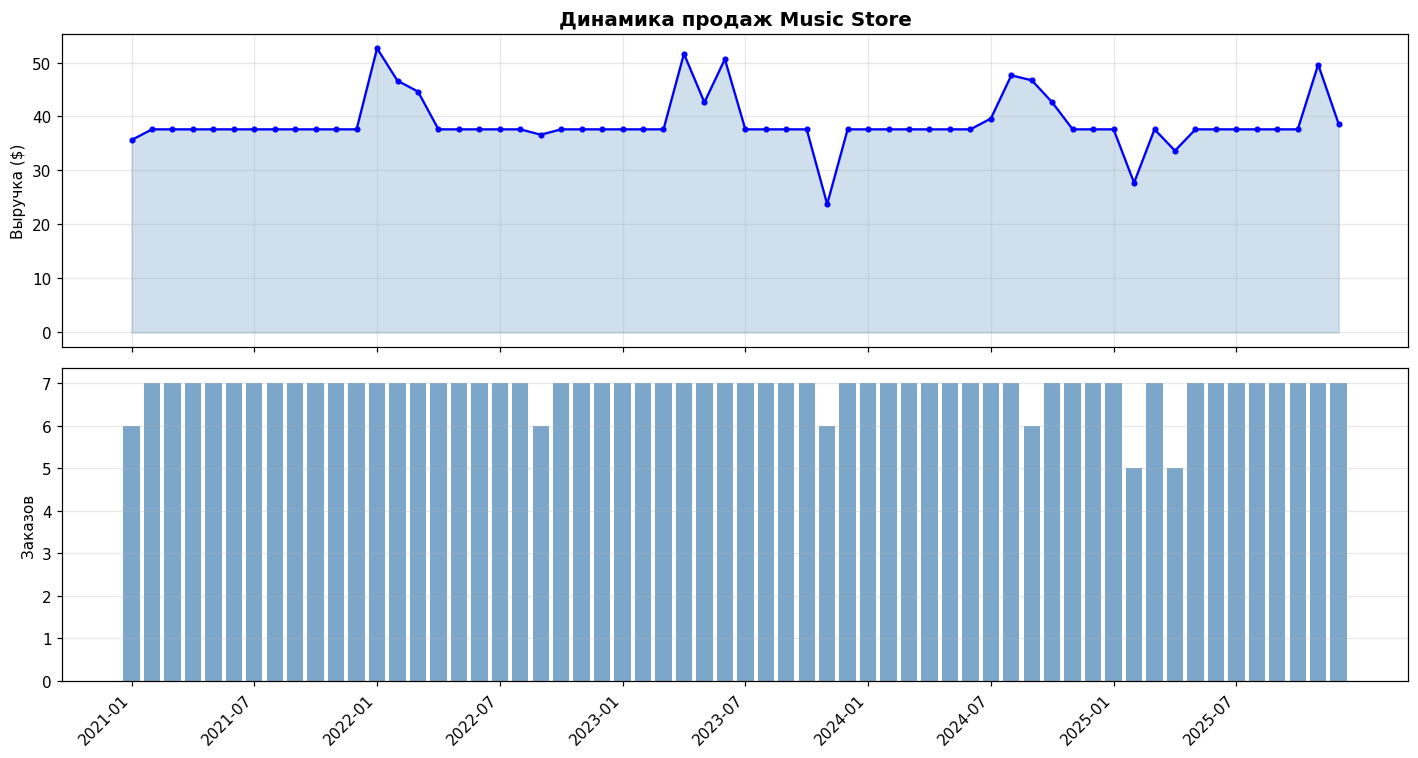

Итого: выручка $2328.60  |  заказов 412


In [62]:
# DEMO ── Динамика выручки по месяцам ────────────────────────────────────────
df_sales = sql("""
SELECT strftime('%Y-%m', InvoiceDate) AS Месяц,
       SUM(Total)       AS Выручка,
       COUNT(InvoiceId) AS Заказов
FROM Invoice
GROUP BY Месяц
ORDER BY Месяц
""")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.fill_between(range(len(df_sales)), df_sales["Выручка"], alpha=0.25, color="steelblue")
ax1.plot(range(len(df_sales)), df_sales["Выручка"], "b-o", markersize=3, linewidth=1.5)
ax1.set_title("Динамика продаж Music Store", fontsize=13, fontweight="bold")
ax1.set_ylabel("Выручка ($)")
ax1.grid(True, alpha=0.3)

ax2.bar(range(len(df_sales)), df_sales["Заказов"], color="steelblue", alpha=0.7)
ax2.set_ylabel("Заказов")
ax2.grid(axis="y", alpha=0.3)

step = 6
ticks = list(range(0, len(df_sales), step))
ax2.set_xticks(ticks)
ax2.set_xticklabels([df_sales["Месяц"].iloc[i] for i in ticks], rotation=45, ha="right")

plt.tight_layout()
plt.savefig("sales_dynamics.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Итого: выручка ${df_sales['Выручка'].sum():.2f}  |  заказов {df_sales['Заказов'].sum()}")


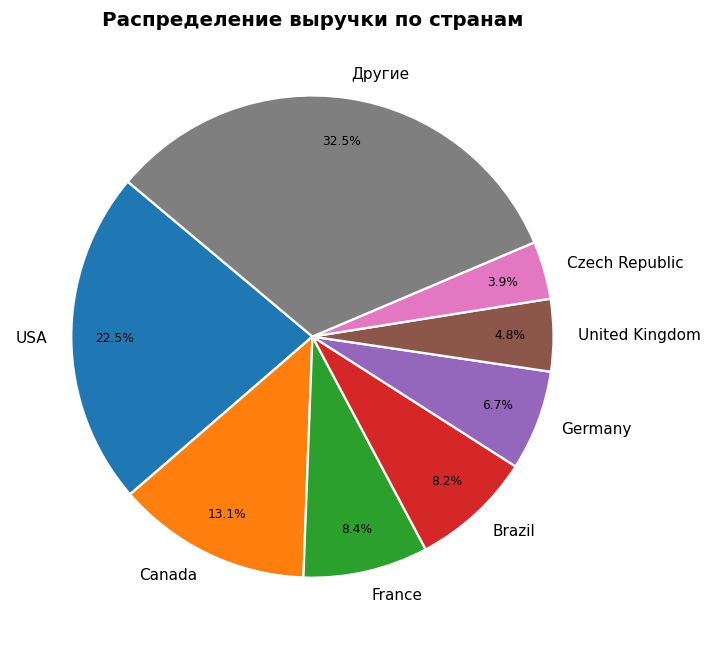

In [63]:
# DEMO ── Топ-10 стран по выручке: круговая диаграмма ────────────────────────
df_ctr = sql("""
SELECT c.Country, ROUND(SUM(i.Total), 2) AS Выручка
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.Country
ORDER BY Выручка DESC
""")

top7  = df_ctr.head(7)
other = pd.DataFrame([["Другие", df_ctr.iloc[7:]["Выручка"].sum()]], columns=["Country","Выручка"])
df_pie = pd.concat([top7, other], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 6))
wedges, texts, autos = ax.pie(
    df_pie["Выручка"], labels=df_pie["Country"],
    autopct="%1.1f%%", startangle=140, pctdistance=0.82,
    wedgeprops=dict(edgecolor="white", linewidth=1.5))
for at in autos: at.set_fontsize(8)
ax.set_title("Распределение выручки по странам", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("revenue_by_country.png", dpi=120, bbox_inches="tight")
plt.show()


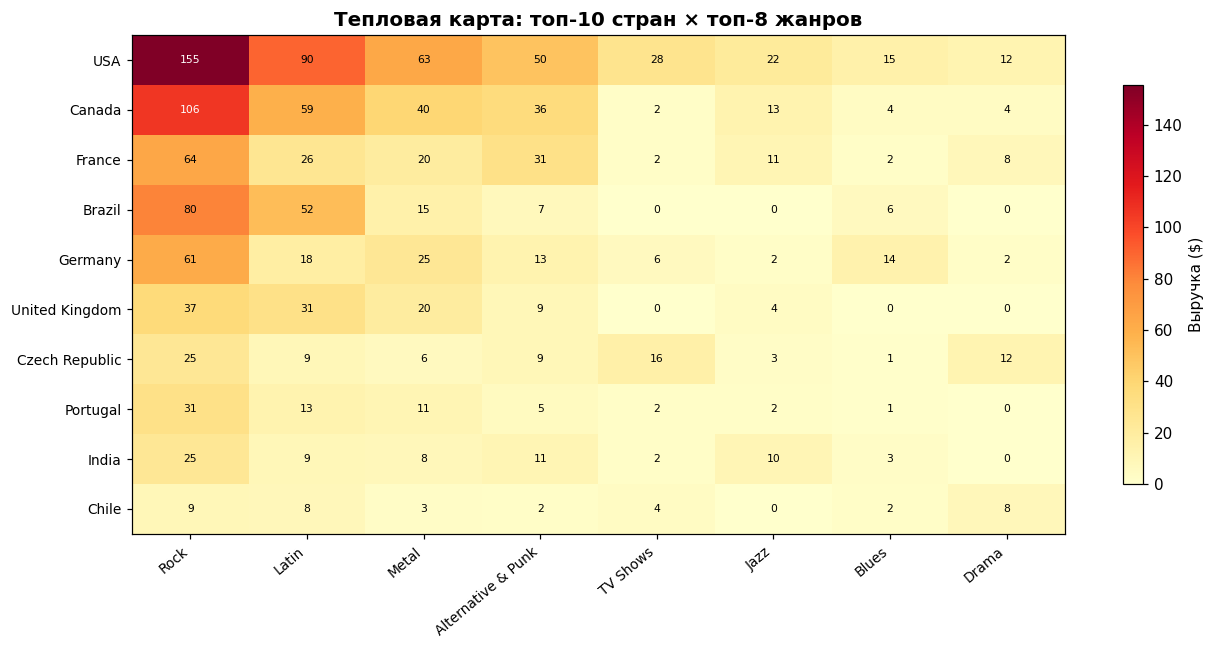

In [64]:
# DEMO ── Тепловая карта: выручка по странам × жанрам ────────────────────────
df_heat = sql("""
SELECT c.Country,
       g.Name  AS Жанр,
       ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS Выручка
FROM Customer    c
JOIN Invoice     i  ON c.CustomerId  = i.CustomerId
JOIN InvoiceLine il ON i.InvoiceId   = il.InvoiceId
JOIN Track       t  ON il.TrackId    = t.TrackId
JOIN Genre       g  ON t.GenreId     = g.GenreId
GROUP BY c.Country, g.GenreId
""")

pivot   = df_heat.pivot_table(values="Выручка", index="Country", columns="Жанр", fill_value=0)
top_c   = df_heat.groupby("Country")["Выручка"].sum().nlargest(10).index
top_g   = df_heat.groupby("Жанр")["Выручка"].sum().nlargest(8).index
p       = pivot.loc[top_c, top_g]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(p.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(p.columns))); ax.set_xticklabels(p.columns, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(len(p.index)));   ax.set_yticklabels(p.index, fontsize=9)
for i in range(len(p.index)):
    for j in range(len(p.columns)):
        v = p.values[i,j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                color="white" if v > p.values.max()*0.6 else "black")
plt.colorbar(im, ax=ax, label="Выручка ($)", shrink=0.8)
ax.set_title("Тепловая карта: топ-10 стран × топ-8 жанров", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


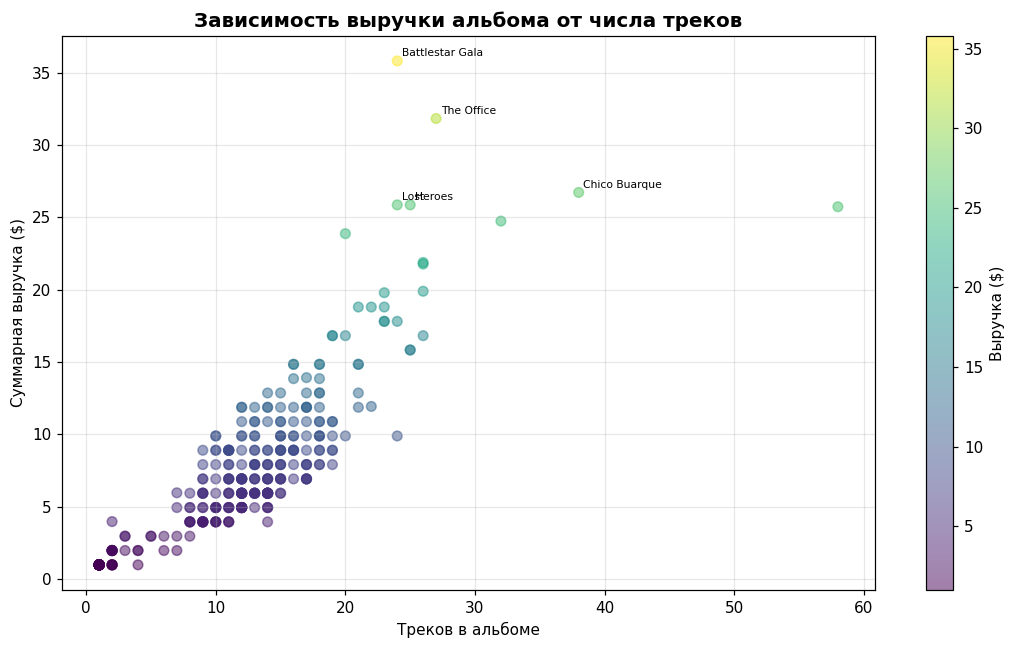

In [65]:
# DEMO ── Scatter plot: треков в альбоме vs выручка ──────────────────────────
df_sc = sql("""
SELECT al.Title                                   AS Альбом,
       ar.Name                                    AS Исполнитель,
       COUNT(t.TrackId)                           AS Треков,
       ROUND(SUM(il.UnitPrice * il.Quantity), 2)  AS Выручка
FROM Album       al
JOIN Artist      ar ON al.ArtistId = ar.ArtistId
JOIN Track       t  ON al.AlbumId  = t.AlbumId
LEFT JOIN InvoiceLine il ON t.TrackId = il.TrackId
GROUP BY al.AlbumId
HAVING Выручка > 0
""")

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df_sc["Треков"], df_sc["Выручка"],
                alpha=0.5, s=40, c=df_sc["Выручка"], cmap="viridis")
plt.colorbar(sc, ax=ax, label="Выручка ($)")
for _, row in df_sc.nlargest(5, "Выручка").iterrows():
    ax.annotate(row["Исполнитель"][:15], (row["Треков"], row["Выручка"]),
                fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("Треков в альбоме")
ax.set_ylabel("Суммарная выручка ($)")
ax.set_title("Зависимость выручки альбома от числа треков", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
<a id="tasks2"></a>
## Самостоятельные задания — Занятие 2

---
### Задание 2.1 — Продвинутый SQL


In [66]:
# ЗАДАНИЕ 2.1.1: CTE — топ-3 альбома каждого исполнителя по числу треков
#
# Используйте CTE + RANK() OVER (PARTITION BY ArtistId ORDER BY COUNT(TrackId) DESC)
# Выведите: Исполнитель, Альбом, Треков, Место
# Фильтр: WHERE Место <= 3

# TODO: ваш код



In [67]:
# ЗАДАНИЕ 2.1.2: LAG — ежемесячная выручка vs предыдущий месяц
#
# 1. CTE: SUM(Total) по strftime('%Y-%m', InvoiceDate)
# 2. Основной SELECT: добавьте Пред_месяц через LAG(Выручка) и Разница
#    Подсказка: LAG(Revenue) OVER (ORDER BY Month)

# TODO: ваш код



In [68]:
# ЗАДАНИЕ 2.1.3: Агенты поддержки с наибольшей суммарной выручкой
#
# Найдите сотрудников, у которых Employee.Title LIKE '%Sales%'
# Выведите: имя, кол-во клиентов, суммарная выручка
# Таблицы: Employee → Customer (SupportRepId) → Invoice
# Ожидаемый результат: 3 агента

# TODO: ваш код



### Задание 2.2 — Визуализация


In [69]:
# ЗАДАНИЕ 2.2.1: Круговая диаграмма — выручка по странам
# Топ-7 + «Другие» в одном секторе
# Требования: заголовок, подписи с процентами

# TODO: SQL

# TODO: matplotlib pie chart



In [70]:
# ЗАДАНИЕ 2.2.2: Scatter plot — треков в альбоме vs выручка
# Ось X: треков в альбоме
# Ось Y: суммарная выручка альбома
# Аннотируйте топ-3 по выручке

# TODO: SQL

# TODO: matplotlib scatter



### Задание 2.3 — Git
1. Создайте ветку `feature/visualization`
2. Добавьте ноутбук с решениями
3. Создайте Pull Request на GitHub с описанием изменений


In [ ]:
# !git checkout -b feature/visualization
# !git add practice_git_python_sql.ipynb
# !git commit -m "Add visualization: pie chart and scatter plot"
# !git push https://YOUR_TOKEN@github.com/YOUR_USERNAME/mini-analysis.git feature/visualization

print("Раскомментируйте и выполните команды")


Раскомментируйте и выполните команды


---
<a id="hw-final"></a>
## Итоговое домашнее задание
> **Срок:** 1 неделя.
> Создайте файл `final_report.ipynb` в репозитории.
> Требования: Markdown-описание к каждому блоку, ≥4 графика, выводы **с числами**.

### Структура репозитория (обязательно):
```
mini-analysis/
├── README.md              ← описание проекта
├── tgu_practice_db.db     ← база данных
├── practice_git_python_sql.ipynb  ← этот ноутбук
└── final_report.ipynb     ← ИТОГОВЫЙ ПРОЕКТ
```


### Вопрос 1: Топ-10 исполнителей по прибыли с разбивкой по жанрам


In [72]:
# ИТОГ Q1: Топ-10 исполнителей по выручке
# Таблицы: Artist → Album → Track → InvoiceLine
# Бонус: добавьте жанр (Genre) к каждому исполнителю (MOST POPULAR genre)
# Визуализация: горизонтальный bar chart

# TODO: SQL



# TODO: matplotlib



# TODO: Markdown-вывод — напишите ниже ячейку Markdown:
# «Лидер по выручке — ??? с суммой $??? ...»


### Вопрос 2: Квартальная выручка и сезонность


In [73]:
# ИТОГ Q2: Выручка по кварталам. Есть ли сезонность?
# Квартал = ((CAST(strftime('%m', InvoiceDate) AS INT) - 1) / 3) + 1
# Подсказка: сгруппируйте по году + кварталу
# Визуализация: линейный или столбчатый график

# TODO: SQL



# TODO: matplotlib





### Вопрос 3: Эффективность агентов поддержки


In [74]:
# ИТОГ Q3: Кто из Sales Support Agent эффективнее?
# Метрики: кол-во клиентов, суммарная выручка, средний чек (Total/кол-во заказов)
# Таблицы: Employee → Customer → Invoice
# Визуализация: grouped bar chart (выручка + клиенты рядом)

# TODO: SQL



# TODO: matplotlib





### Вопрос 4: Разнообразие жанров в плейлистах


In [75]:
# ИТОГ Q4: Какие плейлисты наиболее разнообразны по жанрам?
# Метрика: COUNT(DISTINCT GenreId) на плейлист
# Таблицы: Playlist → PlaylistTrack → Track → Genre
# Визуализация: горизонтальный bar chart

# TODO: SQL



# TODO: matplotlib





### Вопрос 5: LTV клиента по странам


In [ ]:
# 📝 ИТОГ Q5: Среднее значение LTV покупателя по странам
# LTV = суммарная выручка с одного покупателя
# Шаги:
#   CTE 1: SUM(Total) по каждому CustomerId
#   Итог:  GROUP BY Country → AVG(LTV)
# Визуализация: топ-10 стран по среднему LTV

# TODO: SQL



# TODO: matplotlib





### HADR - seaborn / plotly (+10 баллов)


In [76]:
# Переделайте любой из графиков с помощью seaborn или plotly

# ── Пример seaborn ──────────────────────────────────────────────────────────
# import seaborn as sns
# sns.set_theme(style="whitegrid", palette="muted")
# sns.barplot(data=df, x="Выручка_USD", y="Исполнитель")
# plt.title("Топ-10 исполнителей по выручке")
# plt.tight_layout()
# plt.show()

# ── Пример plotly ────────────────────────────────────────────────────────────
# import plotly.express as px
# fig = px.bar(df_sales, x="Месяц", y="Выручка",
#              title="Выручка по месяцам", labels={"Выручка": "Выручка ($)"})
# fig.show()

# TODO: ваш бонусный интерактивный или seaborn-график




---
## Полезные ссылки

| Ресурс | Ссылка |
|--------|--------|
| Google Colab | https://colab.research.google.com |
| GitHub | https://github.com |
| SQLite документация | https://www.sqlite.org/lang.html |
| pandas документация | https://pandas.pydata.org/docs |
| matplotlib gallery | https://matplotlib.org/gallery |
| Git Cheat Sheet | https://education.github.com/git-cheat-sheet-education.pdf |
| SQL Tutorial | https://www.w3schools.com/sql |
| seaborn examples | https://seaborn.pydata.org/examples |
| plotly express | https://plotly.com/python/plotly-express |


